In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from tqdm import tqdm

# Import your custom OOP unconstrainers
from models import NaiveUnconstrainer, EMUnconstrainer, MARSSEMUnconstrainer

# Plotting aesthetics suited for an academic paper
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 7)
plt.rcParams['font.size'] = 12

In [2]:
# 1. Load Data
data_path = '../data/air_cargo_10yr_dataset.csv'
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])

# 2. Isolate Route and sort chronologically (CRITICAL for rolling windows)
sample_df = df[
    (df['Origin'] == 'PVG') & 
    (df['Destination'] == 'LAX')
].copy()

sample_df = sample_df.sort_values('Date').reset_index(drop=True)

# 3. Handle fuzzy capacity (if a flight wasn't perfectly 100k, we use its observed weight as the wall)
# If it wasn't censored, the capacity wall doesn't matter, we just pass 100k as a placeholder.
sample_df['Fuzzy_Capacity'] = np.where(
    sample_df['Is_Censored'], 
    sample_df['Final_Constrained_Bookings'], 
    100000
)

print(f"Total flights for PVG->LAX: {len(sample_df)}")

Total flights for PVG->LAX: 3653


In [ ]:
lookback = 365
total_days = len(sample_df)

# Initialize result columns with NaNs
sample_df['Naive_Est'] = np.nan
sample_df['EM_Est'] = np.nan
sample_df['MARSS_Est'] = np.nan

# Initialize the models
models = {
    'Naive': (NaiveUnconstrainer(), 'Naive_Est'),
    'EM': (EMUnconstrainer(), 'EM_Est'),
    'MARSS': (MARSSEMUnconstrainer(), 'MARSS_Est')
}

print(f"Starting 1-Year Rolling Evaluation (Skipping first {lookback} days as burn-in)...")

# Convert columns to numpy arrays for faster slicing
obs_arr = sample_df['Final_Constrained_Bookings'].values
cens_arr = sample_df['Is_Censored'].values
cap_arr = sample_df['Fuzzy_Capacity'].values

for t in tqdm(range(lookback, total_days)):
    # Print progress every year
    if t % 365 == 0:
        print(f"Processing Year {(t // 365) + 1}...")
        
    # SLICE THE PAST + TODAY: We need the past 364 days + today (total length = 365)
    # The models will fit on this block, and we extract the LAST value (today's estimate)
    win_start = t - lookback + 1
    win_end = t + 1
    
    win_obs = obs_arr[win_start:win_end]
    win_cens = cens_arr[win_start:win_end]
    win_cap = cap_arr[win_start:win_end]
    
    # Run each model on the isolated window
    for name, (model, col_name) in models.items():
        # If today is NOT censored, we don't need to run complex math.
        # Latent demand is simply the observed bookings.
        if not win_cens[-1]:
            sample_df.loc[t, col_name] = win_obs[-1]
            continue
            
        # If today IS censored, unconstrain it using the historical context
        imputed_window = model.fit(
            observed_bookings=win_obs,
            is_censored=win_cens,
            capacity=win_cap,
            max_iter=50 # Cap iterations slightly to speed up rolling window
        )
        
        # Save the very last value in the array (Today's estimate)
        sample_df.loc[t, col_name] = imputed_window[-1]

print("Rolling evaluation complete!")

Starting 1-Year Rolling Evaluation (Skipping first 365 days as burn-in)...
Processing Year 2...
Processing Year 3...
Processing Year 4...
Processing Year 5...
Processing Year 6...
Processing Year 7...
Processing Year 8...
Processing Year 9...
Processing Year 10...
Processing Year 11...
Rolling evaluation complete!


In [4]:
# Filter down to the evaluation period (where we actually made predictions)
eval_df = sample_df.iloc[lookback:].copy()

true_demand = eval_df['Final_True_Demand'].values

print("--- Out-of-Sample Performance Metrics ---")
for name, (_, col_name) in models.items():
    estimated = eval_df[col_name].values
    
    # Calculate RMSE and MAE
    rmse = np.sqrt(np.mean((true_demand - estimated) ** 2))
    mae = np.mean(np.abs(true_demand - estimated))
    
    print(f"{name.ljust(10)} | RMSE: {rmse:,.0f} | MAE: {mae:,.0f}")

--- Out-of-Sample Performance Metrics ---
Naive      | RMSE: 3,542 | MAE: 650
EM         | RMSE: 2,274 | MAE: 395
MARSS      | RMSE: 2,100 | MAE: 378


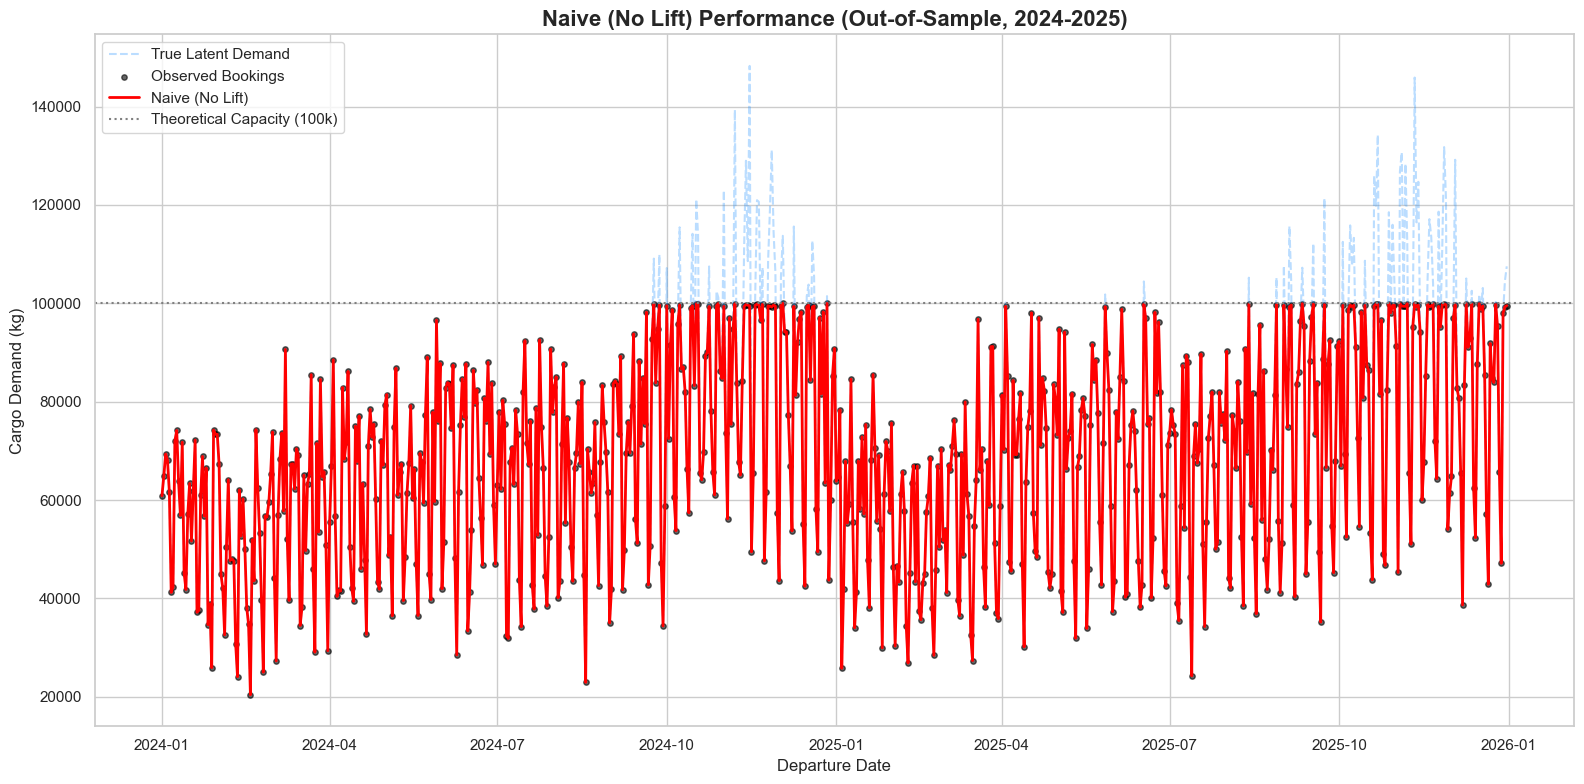

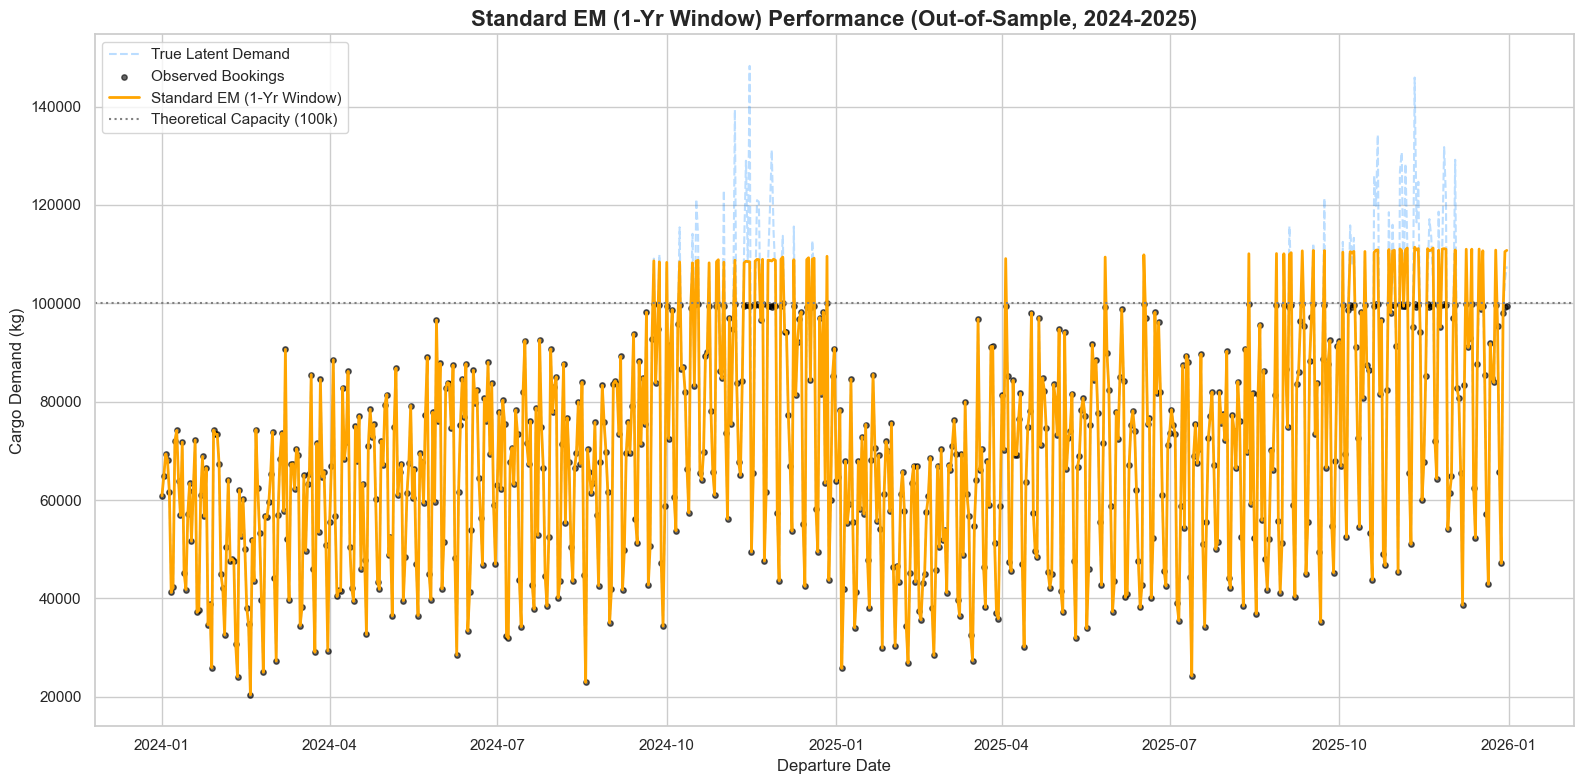

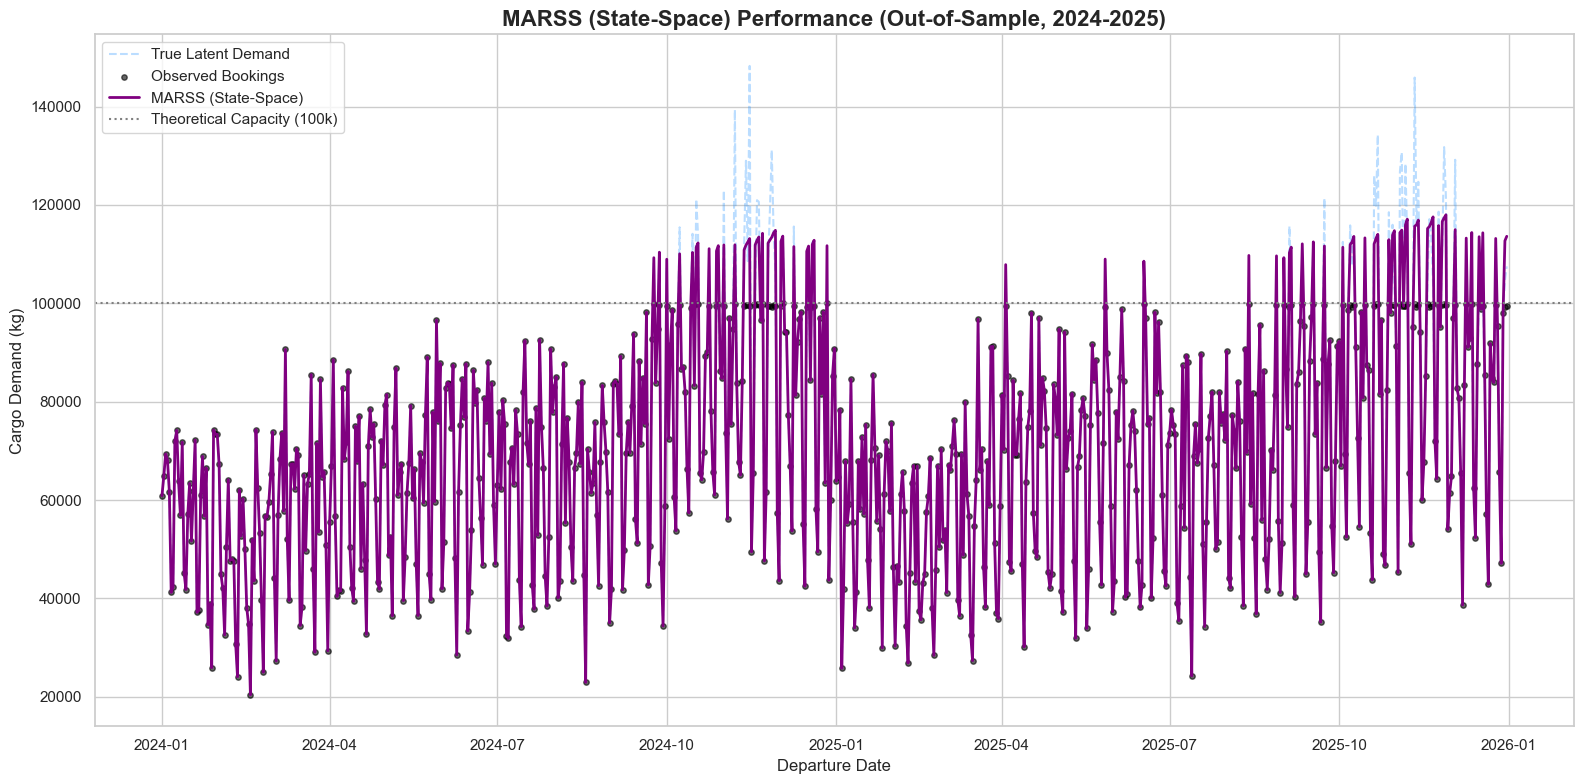

In [8]:
# Zoom in on a specific 2-year window
plot_df = eval_df[
    (eval_df['Date'].dt.year >= 2024) & 
    (eval_df['Date'].dt.year <= 2025)
]

# Common plotting function
def plot_model(model_col, model_name, model_color):
    plt.figure(figsize=(16, 8))
    
    # Ground truth & observations
    plt.plot(
        plot_df['Date'],
        plot_df['Final_True_Demand'],
        label='True Latent Demand',
        color='dodgerblue',
        alpha=0.3,
        linestyle='--'
    )
    
    plt.scatter(
        plot_df['Date'],
        plot_df['Final_Constrained_Bookings'],
        label='Observed Bookings',
        color='black',
        s=15,
        alpha=0.6
    )
    
    # Selected model
    plt.plot(
        plot_df['Date'],
        plot_df[model_col],
        label=model_name,
        color=model_color,
        linewidth=2
    )
    
    # Capacity line
    plt.axhline(
        y=100000,
        color='gray',
        linestyle=':',
        label='Theoretical Capacity (100k)'
    )
    
    plt.title(
        f'{model_name} Performance (Out-of-Sample, 2024-2025)',
        fontsize=16,
        fontweight='bold'
    )
    plt.ylabel('Cargo Demand (kg)', fontsize=12)
    plt.xlabel('Departure Date', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()


# Plot each model separately
plot_model('Naive_Est', 'Naive (No Lift)', 'red')
plot_model('EM_Est', 'Standard EM (1-Yr Window)', 'orange')
plot_model('MARSS_Est', 'MARSS (State-Space)', 'purple')